# ConnectTel Customer Churn Prediction

## Project Overview

ConnectTel aims to predict customers who are likely to churn so that the retention team can take proactive action.

This project develops an end-to-end machine learning pipeline including:

- Exploratory Data Analysis (EDA)
- Feature Engineering
- Data Preprocessing
- Logistic Regression
- Random Forest
- XGBoost
- Hyperparameter Tuning using GridSearchCV
- Model Evaluation using Accuracy, Precision, Recall, F1 Score and ROC-AUC
- SHAP-based Model Interpretability
- Business Insights and Customer Retention Recommendations

### Objective

To build a reliable and interpretable classification model that identifies customers at high risk of churn and helps ConnectTel design effective retention strategies.

In [92]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [93]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [94]:
df.shape
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [95]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [96]:
df.isnull().sum()


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [97]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [98]:
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
churn_percentage

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

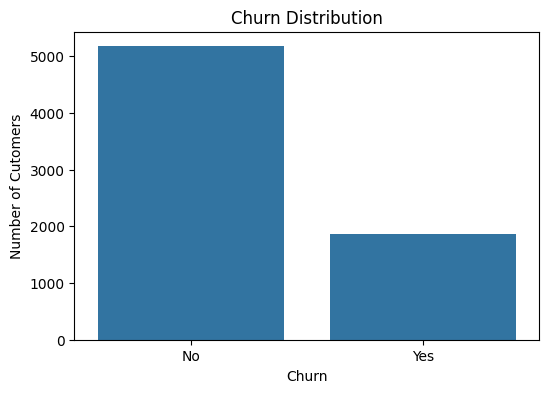

In [99]:
plt.figure(figsize=(6,4))

sns.countplot(data=df , x="Churn")
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Cutomers")

plt.show()

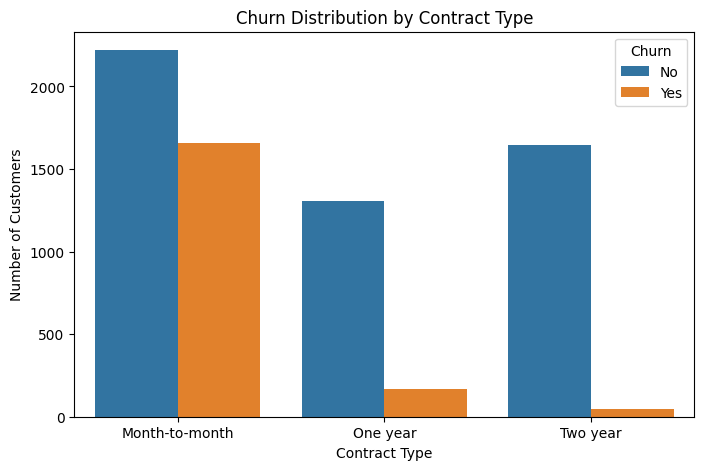

In [100]:
plt.figure(figsize=(8,5))

sns.countplot(data=df , x="Contract" , hue="Churn")
plt.title("Churn Distribution by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

In [101]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


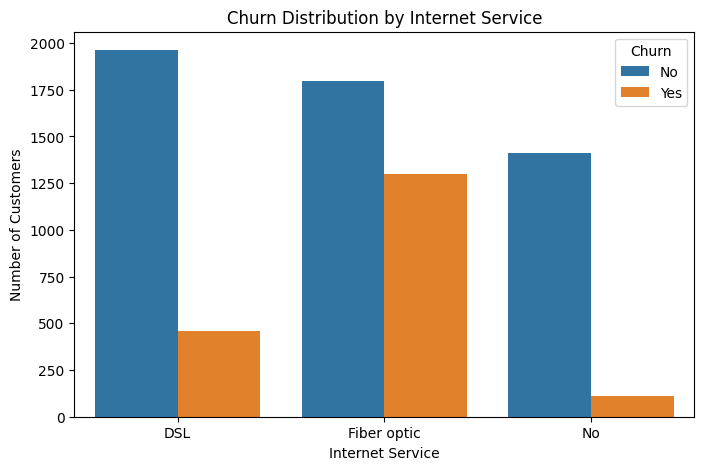

In [102]:
plt.figure(figsize=(8,5))

sns.countplot(data=df , x="InternetService" , hue="Churn")
plt.title("Churn Distribution by Internet Service")
plt.xlabel("Internet Service")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

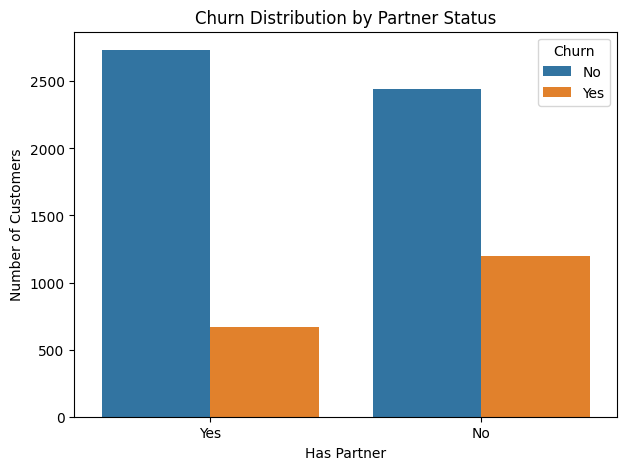

In [103]:
plt.figure(figsize=(7,5))
sns.countplot(data=df , x="Partner" , hue="Churn")
plt.title("Churn Distribution by Partner Status")
plt.xlabel("Has Partner")
plt.ylabel("Number of Customers")
plt.legend(title="Churn")
plt.show()

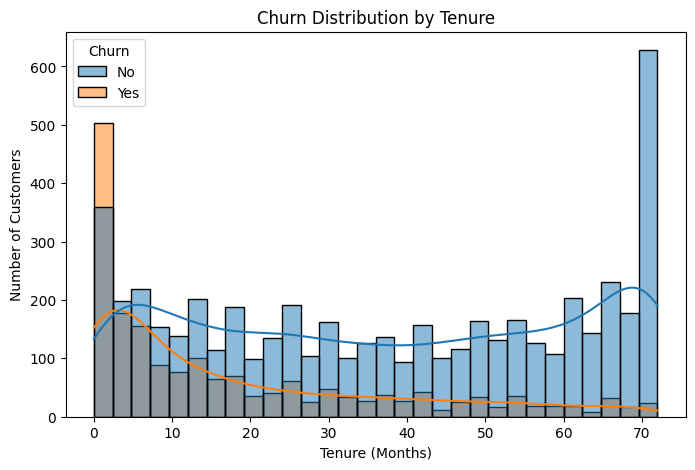

In [104]:
plt.figure(figsize=(8,5))
sns.histplot(
    data=df,
    x="tenure",
    hue="Churn",
    bins=30,
    kde=True
)

plt.title("Churn Distribution by Tenure")
plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.show()

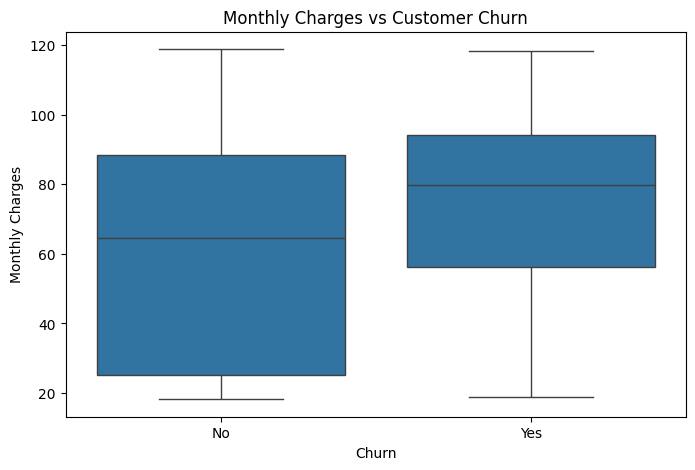

In [105]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df,x="Churn",y="MonthlyCharges")

plt.title("Monthly Charges vs Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [106]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

df["TotalChargesPerTenure"] = (
    df["TotalCharges"] / 
df["tenure"].replace(0, np.nan)    
)
df[["tenure","TotalCharges",
"TotalChargesPerTenure"]].head()


,tenure,TotalCharges,TotalChargesPerTenure
0,1,29.85,29.850000
1,34,1889.50,55.573529
2,2,108.15,54.075000
3,45,1840.75,40.905556
4,2,151.65,75.825000


In [107]:
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
    ]
df["ServiceCount"] = 0

for col in service_columns:
    df["ServiceCount"] += (df[col]=="Yes").astype(int)

    df[["ServiceCount","Churn"]].head()

In [108]:
df["HasStreaming"]=(
    (df["StreamingTV"] == "Yes")|
    (df["StreamingMovies"]=="Yes")
).astype(int)

df[["StreamingTV","StreamingMovies","HasStreaming","Churn"]].head()

,StreamingTV,StreamingMovies,HasStreaming,Churn
0,No,No,0,No
1,No,No,0,No
2,No,No,0,Yes
3,No,No,0,No
4,No,No,0,Yes


In [109]:
df.columns.tolist()

['customerID',
 'gender',
 'SeniorCitizen',
 'Partner',
 'Dependents',
 'tenure',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'MonthlyCharges',
 'TotalCharges',
 'Churn',
 'TotalChargesPerTenure',
 'ServiceCount',
 'HasStreaming']

In [110]:
# Convert TotalCharges into numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Feature 1
df["TotalChargesPerTenure"] = (
    df["TotalCharges"] / df["tenure"].replace(0, np.nan)
)

# Feature 2
service_columns = [
    "PhoneService",
    "MultipleLines",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["ServiceCount"] = 0

for col in service_columns:
    df["ServiceCount"] += (df[col] == "Yes").astype(int)

# Feature 3
df["HasStreaming"] = (
    (df["StreamingTV"] == "Yes") |
    (df["StreamingMovies"] == "Yes")
).astype(int)

df[["TotalChargesPerTenure", "ServiceCount", "HasStreaming"]].head()

,TotalChargesPerTenure,ServiceCount,HasStreaming
0,29.850000,1,0
1,55.573529,3,0
2,54.075000,3,0
3,40.905556,3,0
4,75.825000,1,0


In [111]:
df.isnull().sum().sort_values(ascending=False).head(10)

TotalCharges             11
TotalChargesPerTenure    11
customerID                0
gender                    0
Dependents                0
tenure                    0
SeniorCitizen             0
Partner                   0
MultipleLines             0
PhoneService              0
dtype: int64

In [112]:
df["TotalCharges"]= df["TotalCharges"].fillna(0)

df["TotalChargesPerTenure"]= df["TotalChargesPerTenure"].fillna(0)

df.isnull().sum().sum()


np.int64(0)

In [113]:
x= df.drop(columns=["Churn","customerID"])
y= df["Churn"].map({"Yes":1,"No":0})

print("x shape:",x.shape)
print("y shape:",y.shape)

x shape: (7043, 22)
y shape: (7043,)


In [114]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Identify numerical and categorical columns
numerical_features = x.select_dtypes(include=["int64", "float64"]).columns
categorical_features = x.select_dtypes(include=["object"]).columns

# Create preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

print("Numerical features:", len(numerical_features))
print("Categorical features:", len(categorical_features))

Numerical features: 7
Categorical features: 15


C:\Users\hp\AppData\Local\Temp\ipykernel_10236\1891741881.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = x.select_dtypes(include=["object"]).columns


In [115]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set shape:", x_train.shape)
print("Test set shape:", x_test.shape)

Training set shape: (5634, 22)
Test set shape: (1409, 22)


In [116]:
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

print("Processed training set shape:", x_train_processed.shape)
print("Processed test set shape:", x_test_processed.shape)

Processed training set shape: (5634, 48)
Processed test set shape: (1409, 48)


In [117]:
from sklearn.linear_model import LogisticRegression
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(x_train_processed, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [118]:
y_pred = logistic_model.predict(x_test_processed)
y_pred = logistic_model.predict_proba(x_test_processed)[:, 1]
print("Predictions generated successfully!")

Predictions generated successfully!


In [119]:
print("Capital X:", "X_train_processed" in globals())
print("Small x:", "x_train_processed" in globals())

print("Capital X test:", "X_test_processed" in globals())
print("Small x test:", "x_test_processed" in globals())

Capital X: True
Small x: True
Capital X test: True
Small x test: True


In [120]:
import pandas as pd
import numpy as np
df=pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print("Dataset loaded successfully!")
print(df.shape)

Dataset loaded successfully!
(7043, 21)


In [121]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Separate features and target
X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"].map({"Yes": 1, "No": 0})

# Identify columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns
categorical_features = X.select_dtypes(include=["object"]).columns

# Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Apply preprocessing
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessing completed successfully!")
print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Preprocessing completed successfully!
Training shape: (5634, 5320)
Testing shape: (1409, 5320)


C:\Users\hp\AppData\Local\Temp\ipykernel_10236\3816309243.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_features = X.select_dtypes(include=["object"]).columns


In [122]:
from sklearn.linear_model import LogisticRegression

# Train model again
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_processed, y_train)

# Predictions
y_pred = logistic_model.predict(X_test_processed)

# Churn probabilities
y_pred_proba = logistic_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully!")
print("First 5 probabilities:", y_pred_proba[:5])

Predictions generated successfully!
First 5 probabilities: [0.03286906 0.70502069 0.06194178 0.4014102  0.02319625]


In [123]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("Accuracy :", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall   :", round(recall, 4))
print("F1 Score :", round(f1, 4))
print("AUC-ROC  :", round(auc, 4))

Accuracy : 0.7942
Precision: 0.6312
Recall   : 0.5401
F1 Score : 0.5821
AUC-ROC  : 0.8403


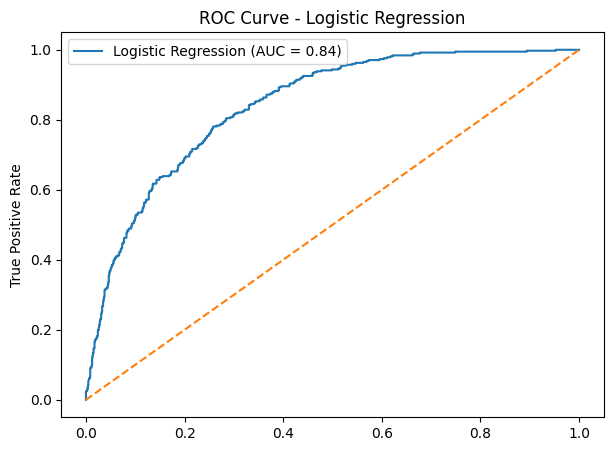

In [124]:
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
plt.figure(figsize=(7,5))
plt.plot(fpr,tpr,label=f"Logistic Regression (AUC = {auc:.2f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.title("ROC Curve - Logistic Regression")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

In [125]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
rf_model.fit(X_train_processed, y_train)
print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [126]:
rf_pred=rf_model.predict(X_test_processed)
rf_pred_proba=rf_model.predict_proba(X_test_processed)[:,1]
print("Random Forest predictions generated successfully!")

Random Forest predictions generated successfully!


In [127]:
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred)
rf_recall = recall_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_pred_proba)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("AUC-ROC   :", round(rf_auc, 4))

Random Forest Results
---------------------
Accuracy : 0.7615
Precision: 0.5436
Recall   : 0.6337
F1-Score : 0.5852
AUC-ROC   : 0.8171


In [128]:
model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "Precision": [precision, rf_precision],
    "Recall": [recall, rf_recall],
    "F1-Score": [f1, rf_f1],
    "AUC-ROC": [auc, rf_auc]
})

In [129]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores = cross_val_score(
    logistic_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="roc_auc"
)

print("5-Fold ROC-AUC Scores:")
print(cv_scores)

print("Mean ROC-AUC:", round(cv_scores.mean(), 4))

5-Fold ROC-AUC Scores:
[0.84582667 0.82395626 0.84484918 0.86110101 0.85168215]
Mean ROC-AUC: 0.8455


In [130]:
rf_cv_scores = cross_val_score(
    rf_model,
    X_train_processed,
    y_train,
    cv=cv,
    scoring="roc_auc"
)
print("5-Fold ROC-AUC Scores:")
print(rf_cv_scores)
print("Mean ROC-AUC:", round(rf_cv_scores.mean(), 4))

5-Fold ROC-AUC Scores:
[0.81811958 0.81373297 0.82442077 0.82796722 0.84272039]
Mean ROC-AUC: 0.8254


In [131]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(n_estimators=200,learning_rate=0.05,max_depth=4,random_state=42,eval_metric="logloss")
xgb_model.fit(X_train_processed, y_train)
print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [132]:
xgb_pred=xgb_model.predict(X_test_processed)
xgb_pred_proba=xgb_model.predict_proba(X_test_processed)[:,1]
print("XGBoost predictions generated successfully!")

XGBoost predictions generated successfully!


In [133]:
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_auc = roc_auc_score(y_test, xgb_pred_proba)

print("XGBoost Results")
print("---------------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1-Score :", round(xgb_f1, 4))
print("AUC-ROC   :", round(xgb_auc, 4))

XGBoost Results
---------------------
Accuracy : 0.8062
Precision: 0.6735
Recall   : 0.5241
F1-Score : 0.5895
AUC-ROC   : 0.8438


In [134]:
final_comparision=pd.DataFrame({"Model":["Logistic Regression","Random Forest","XGBoost"],
                                "Accuracy":[accuracy,rf_accuracy,xgb_accuracy],
                                "Precision":[precision,rf_precision,xgb_precision],
                                "Recall":[recall,rf_recall,xgb_recall],
                                "F1-Score":[f1,rf_f1,xgb_f1],
                                "AUC-ROC":[auc,rf_auc,xgb_auc]
                                })
final_comparision

,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,Logistic Regression,0.794180,0.631250,0.540107,0.582133,0.840298
1,Random Forest,0.761533,0.543578,0.633690,0.585185,0.817079
2,XGBoost,0.806246,0.673540,0.524064,0.589474,0.843762


In [135]:
from sklearn.model_selection import GridSearchCV
param_grid ={
    "n_estimators":[100,200],
    "max_depth":[3,4,5],
    "learning_rate":[0.01,0.05,0.1]
}
grid_search = GridSearchCV(
    estimator=XGBClassifier(
    random_state=42,
    eval_metric="logloss"),
param_grid=param_grid,
cv=5,
scoring="roc_auc",
n_jobs=-1
)




grid_search.fit(X_train_processed,y_train)
print("Best parameters:")
print(grid_search.best_params_)
print("Best Cross-Vlidation AUC:") 
print(round(grid_search.best_score_,4))


Best parameters:
{'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100}
Best Cross-Vlidation AUC:
0.8483


In [136]:
best_xgb_model = grid_search.best_estimator_
bestxgb_pred=best_xgb_model.predict(X_test_processed)
bestxgb_pred_proba=best_xgb_model.predict_proba(X_test_processed)[:,1]
bestxgb_accuracy = accuracy_score(y_test, bestxgb_pred)
bestxgb_precision = precision_score(y_test, bestxgb_pred)
bestxgb_recall = recall_score(y_test, bestxgb_pred)
bestxgb_f1 = f1_score(y_test, bestxgb_pred)
bestxgb_auc = roc_auc_score(y_test, bestxgb_pred_proba)

print("Turned XGBoost Results")
print("-----------------------")
print("Accuracy: ",round(bestxgb_accuracy, 4))
print("Precision: ",round(bestxgb_precision, 4))
print("Recall: ",round(bestxgb_recall, 4))
print("F1-Score: ",round(bestxgb_f1, 4))
print("AUC-ROC: ",round(bestxgb_auc, 4))

Turned XGBoost Results
-----------------------
Accuracy:  0.8062
Precision:  0.6784
Recall:  0.5134
F1-Score:  0.5845
AUC-ROC:  0.8458


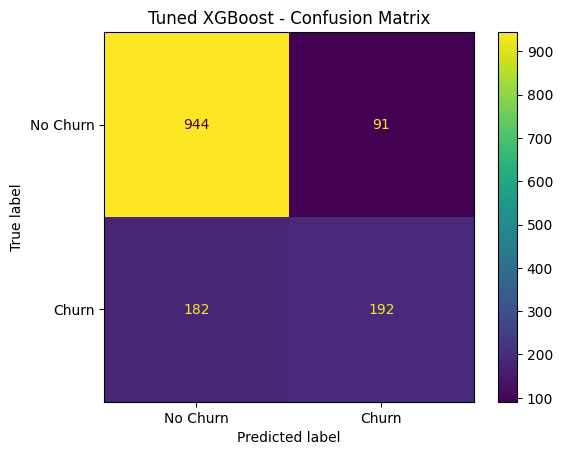

In [137]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

best_xgb_pred = grid_search.best_estimator_.predict(X_test_processed)

cm_xgb = confusion_matrix(y_test, best_xgb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_xgb,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.title("Tuned XGBoost - Confusion Matrix")
plt.show()

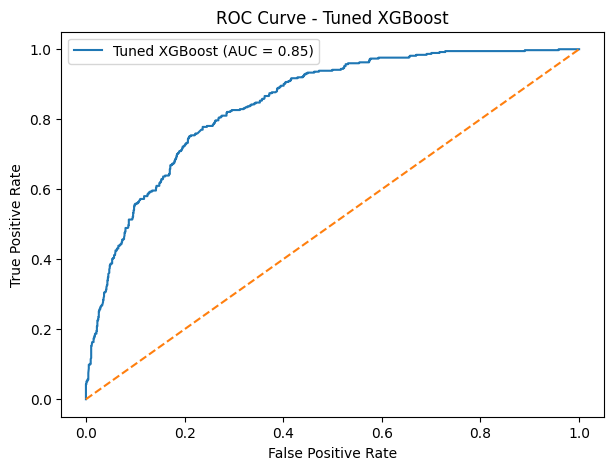

In [138]:
from sklearn.metrics import roc_curve

best_xgb_pred_proba = grid_search.best_estimator_.predict_proba(X_test_processed)[:, 1]

xgb_fpr, xgb_tpr, _ = roc_curve(y_test, best_xgb_pred_proba)

plt.figure(figsize=(7, 5))

plt.plot(
    xgb_fpr,
    xgb_tpr,
    label=f"Tuned XGBoost (AUC = {roc_auc_score(y_test, best_xgb_pred_proba):.2f})"
)

plt.plot([0, 1], [0, 1], linestyle="--")

plt.title("ROC Curve - Tuned XGBoost")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

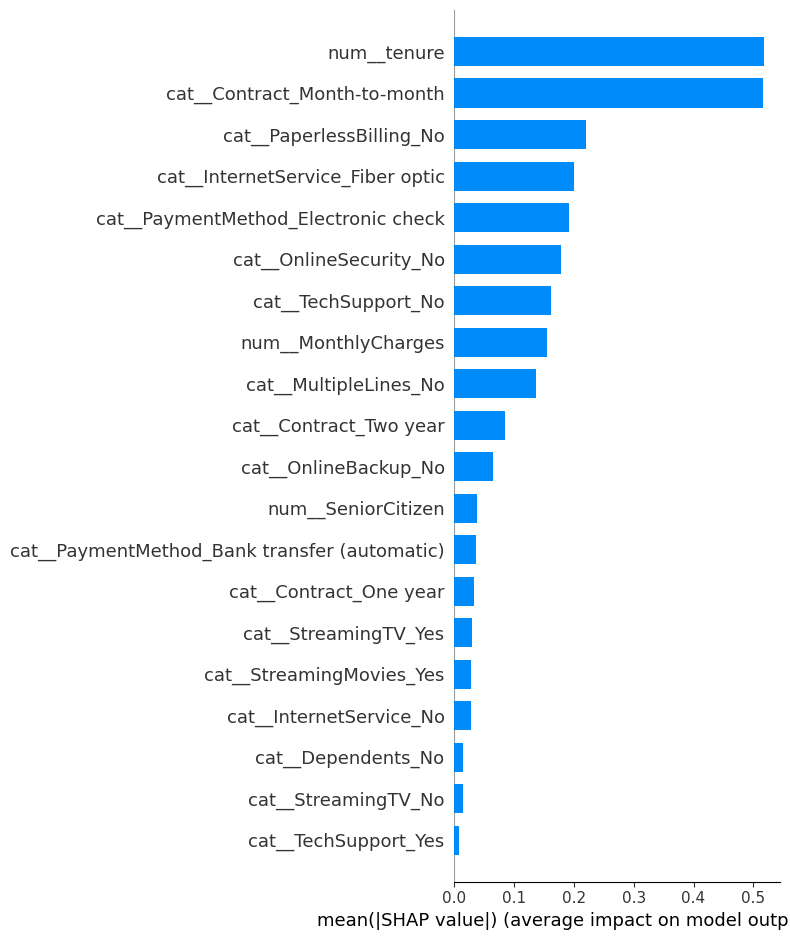

In [139]:
import shap

feature_names=preprocessor.get_feature_names_out()
X_test_dense = X_test_processed.toarray() if hasattr(X_test_processed, "toarray") else X_test_processed

explainer = shap.TreeExplainer(grid_search.best_estimator_)
shap_values = explainer.shap_values(X_test_dense)
shap.summary_plot(
    shap_values, X_test_dense, feature_names=feature_names,plot_type="bar")

In [140]:
shap_importance = pd.DataFrame({"Feature": feature_names, "Importance": np.abs(shap_values).mean(axis=0)})
shap_importance.sort_values(by="Importance", ascending=False)
shap_importance.head(10)

,Feature,Importance
0,num__SeniorCitizen,0.037967
1,num__tenure,0.518648
2,num__MonthlyCharges,0.154699
3,cat__gender_Female,0.004186
4,cat__gender_Male,0.000000
5,cat__Partner_No,0.000000
6,cat__Partner_Yes,0.000000
7,cat__Dependents_No,0.015160
8,cat__Dependents_Yes,0.000000
9,cat__PhoneService_No,0.003973


In [141]:
final_model_comparision = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy" : [accuracy, rf_accuracy, xgb_accuracy, bestxgb_accuracy],
    "Precision" :[precision, rf_precision, xgb_precision, bestxgb_precision],
    "Recall" : [recall, rf_recall, xgb_recall, bestxgb_recall],    
    "F1 Score": [f1, rf_f1, xgb_f1, bestxgb_f1], 
    "AUC-ROC": [auc, rf_auc, xgb_auc, roc_auc_score(y_test, best_xgb_pred_proba)]                                          
})
final_model_comparision.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,AUC-ROC
0,Logistic Regression,0.7942,0.6312,0.5401,0.5821,0.8403
1,Random Forest,0.7615,0.5436,0.6337,0.5852,0.8171
2,XGBoost,0.8062,0.6735,0.5241,0.5895,0.8438
3,Tuned XGBoost,0.8062,0.6784,0.5134,0.5845,0.8458


In [142]:
best_model_row = final_model_comparision.loc[final_model_comparision["AUC-ROC"].idxmax()]
best_model_row

Model        Tuned XGBoost
Accuracy          0.806246
Precision         0.678445
Recall            0.513369
F1 Score          0.584475
AUC-ROC           0.845801
Name: 3, dtype: object

## Buisness Insights and Recommendations

### Key Insights
- Month-tomonth customers are more likely to churn than customers on long-term contracts.
- Customers using fiber optic internet show higher churn risk compared with DSL cutomers.
- Customer tenure is an important factor in predicting churn, especially for newer customers.
- Monthly charges have an important relationship with customer churn.
- The SHAP analysis identifies the major factors that influence individual churn predictions.

### Business Recommendations
1. **Target month-to-month customers:** Offer discounts or incentives to encourage customers to move to one-year or two-year contracts.
2. **Focus on new customers:** Provide onboarding support and early retention offers during the first few months.
3. **Review high-charge customers:** Offer suitable plans or discounts to customers with high monthly charges.
4. **Improve fiber customer experience:** Investigate service quality, pricing, and support issues among fiber customers.
5. **Use the churn model proactively:** Send high-risk customer lists to the retention team so they can intervene before customers leave.
6. **Personalize retention offers:** Use SHAP-based insights to understand why an individual customer is at risk and provide a relevant offer

## Conclusion

The ConnectTel Customer Churn Prediction project successfully developed an end-to-end machine learning pipeline for identifying customers at risk of churn.

Multiple classification models were trained and evaluated, including Logistic Regression, Random Forest, and XGBoost. Hyperparameter tuning was performed using GridSearchCV to improve the XGBoost model.

SHAP analysis was used to understand the key factors influencing customer churn predictions. These insights can help ConnectTel identify high-risk customers and take proactive retention actions.

The model can support the retention team in making data-driven decisions and designing personalized customer retention strategies.